Базова температура рослини:

In [15]:
base_temperature = 48

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('temperature.csv')

df.head()


,date,temperature
0,2025-11-04T23:25:00+02:00,47.68
1,2025-11-04T23:35:00+02:00,51.25
2,2025-11-04T23:45:00+02:00,49.39
3,2025-11-04T23:49:02+02:00,47.15
4,2025-11-04T23:49:12+02:00,46.16


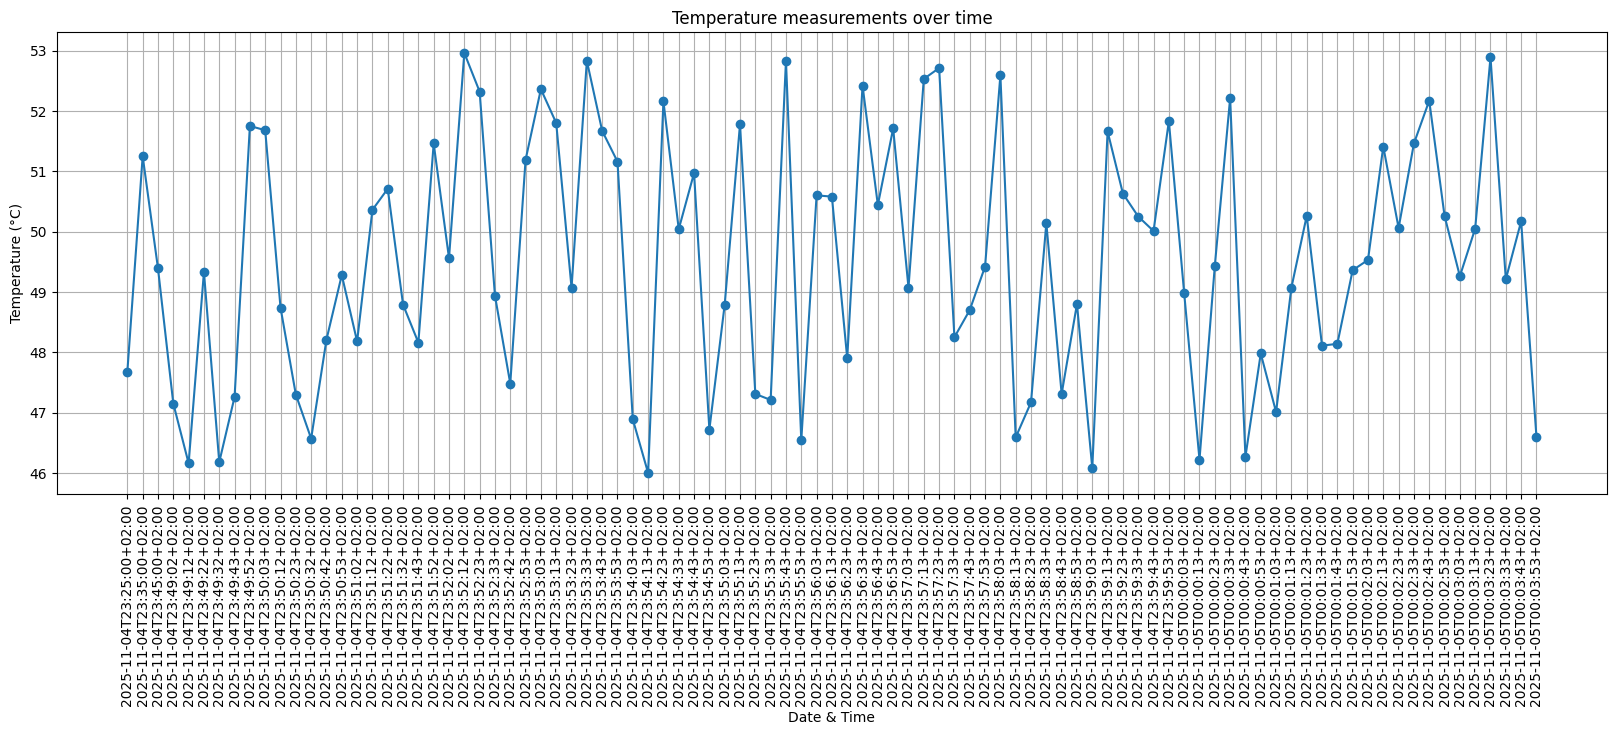

In [17]:
plt.figure(figsize=(20, 6))
plt.plot(df['date'], df['temperature'], linestyle='-', marker='o')
plt.title("Temperature measurements over time")
plt.xlabel("Date & Time")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=90)
plt.grid()
plt.show()


In [18]:
# Convert datetime strings into datetime objects and extract the date
df['date'] = pd.to_datetime(df['date']).dt.date

# Group by date
data_by_date = df.groupby('date')

# Minimum and maximum temperature for each day
min_by_date = data_by_date.min()
max_by_date = data_by_date.max()

# Merge min and max values into one table
min_max_by_date = min_by_date.join(max_by_date, lsuffix='_min', rsuffix='_max')
min_max_by_date = min_max_by_date.reset_index()

min_max_by_date


,date,temperature_min,temperature_max
0,2025-11-04,46.00,52.96
1,2025-11-05,46.22,52.89


In [19]:
def calculate_gdd(row):
    avg_temp = (row['temperature_max'] + row['temperature_min']) / 2
    return max(avg_temp - base_temperature, 0)   # GDD cannot be negative

# Apply formula
min_max_by_date['gdd'] = min_max_by_date.apply(calculate_gdd, axis=1)

# Display results
print(min_max_by_date[['date', 'temperature_min', 'temperature_max', 'gdd']].to_string(index=False))

# Save results to new CSV
min_max_by_date.to_csv("gdd_results.csv", index=False)


      date  temperature_min  temperature_max   gdd
2025-11-04            46.00            52.96 1.480
2025-11-05            46.22            52.89 1.555


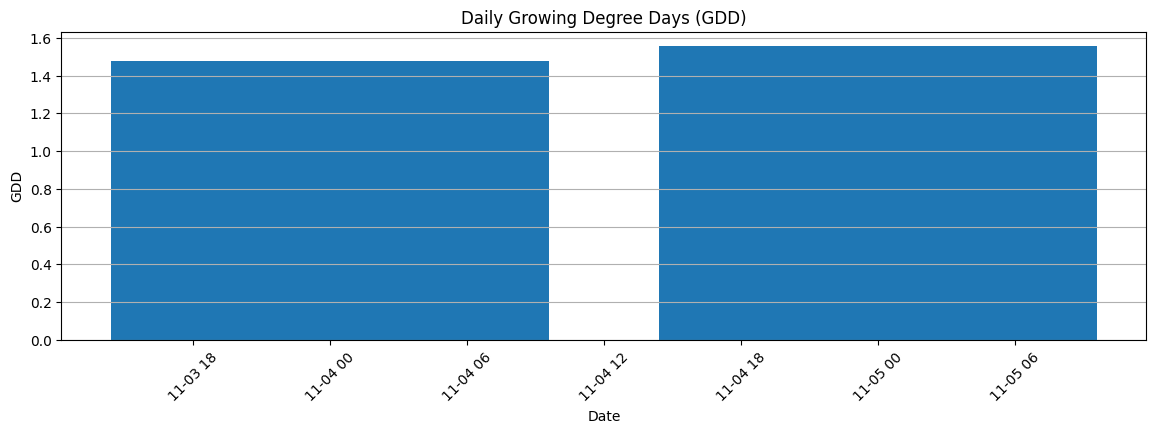

In [20]:
plt.figure(figsize=(14,4))
plt.bar(min_max_by_date['date'], min_max_by_date['gdd'])
plt.title("Daily Growing Degree Days (GDD)")
plt.xlabel("Date")
plt.ylabel("GDD")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


In [21]:
total_gdd = min_max_by_date['gdd'].sum()
print(f"Total accumulated GDD: {total_gdd:.2f}")


Total accumulated GDD: 3.04
